# Machine Learning Essentials SS25 - Exercise Sheet 10

## Instructions
- `TODO`'s indicate where you need to complete the implementations.
- You may use external resources, but <b>write your own solutions</b>.
- Provide concise, but comprehensible comments to explain what your code does.
- Code that's unnecessarily extensive and/or not well commented will not be scored.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.datasets import make_regression, load_diabetes
from sklearn.preprocessing import StandardScaler


# Set a consistent style for the plots
sns.set_theme(style="whitegrid")

## Exercise 2

### Task 1

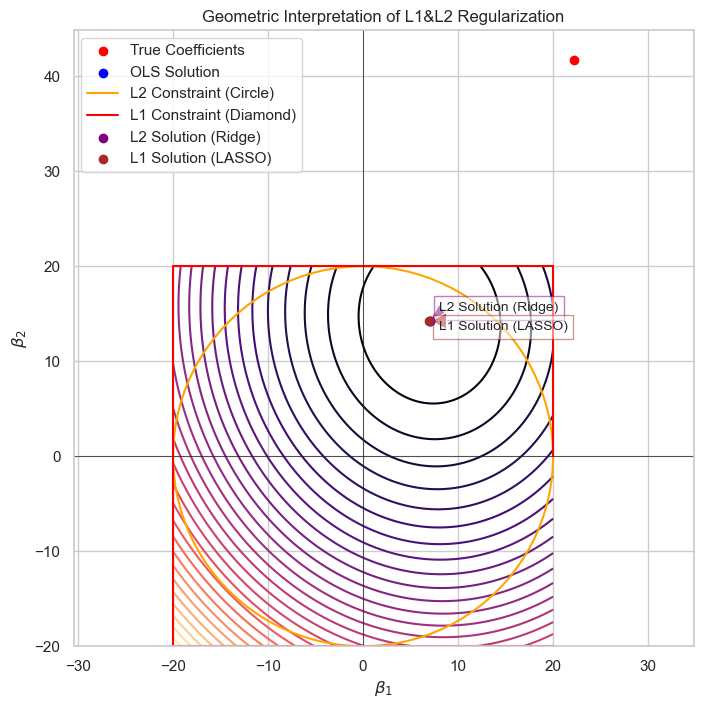

In [16]:
# Generate 2D sampel data
X_reg, y_reg, coef_true = make_regression(
    n_samples=50, n_features=2, n_informative=2, noise=5, coef=True, random_state=42
)

# Scale up data for visualization purposes (this gives smaller betas)
X_reg *= 3

# TODO: Compute OLS solution and RSS function
ols_model = LinearRegression()
def rss(beta):
    # Compute RSS for a given beta (assume no intercept)
    residuals = y_reg - (X_reg @ beta)
    return np.sum(residuals ** 2)

# Create grid for contour plot
beta1_vals = np.linspace(-20, 20, 200)
beta2_vals = np.linspace(-20, 20, 200)
B1, B2 = np.meshgrid(beta1_vals, beta2_vals)
RSS_vals = np.array([rss(np.array([b1, b2])) for b1, b2 in zip(np.ravel(B1), np.ravel(B2))])
RSS_vals = RSS_vals.reshape(B1.shape)


# TODO: Set an appropriate "radius" (or multiple) for the L1/L2 constraint
s = 20

# TODO: Compute L2/L1 solutions. L2 (Ridge) solution could be computed analytically. For L1 (LASSO), use sklearn's Lasso, since we can't compute it analytically (think about why). Set L1's alpha to a value that places the solution on a point where beta_2 is zero

# Fit OLS model once and reuse
ols_model.fit(X_reg, y_reg)
beta_l2 = ols_model.coef_
beta_l1 = Lasso(alpha=0.1).fit(X_reg, y_reg).coef_


plt.figure(figsize=(8, 8))

# (a) TODO: Plot RSS Contours and OLS solution 
plt.contour(B1, B2, RSS_vals, levels=30, cmap='magma')
plt.scatter(coef_true[0], coef_true[1], color='red', label='True Coefficients', zorder=5)
plt.scatter(beta_l2[0], beta_l2[1], color='blue', label='OLS Solution', zorder=5)

# (b) TODO: Plot L1/L2 Constraint (Circle/Diamond)
plt.plot(s * np.cos(np.linspace(0, 2 * np.pi, 100)), s * np.sin(np.linspace(0, 2 * np.pi, 100)), color='orange', label='L2 Constraint (Circle)')
plt.plot(s * np.sign(np.cos(np.linspace(0, 2 * np.pi, 100))), s * np.sign(np.sin(np.linspace(0, 2 * np.pi, 100))), color='red', label='L1 Constraint (Diamond)')
plt.scatter(beta_l2[0], beta_l2[1], color='purple', label='L2 Solution (Ridge)', zorder=5)
plt.scatter(beta_l1[0], beta_l1[1], color='brown', label='L1 Solution (LASSO)', zorder=5)


# (c) TODO: Create Labels/Markers for Ridge/LASSO solution
plt.annotate('L2 Solution (Ridge)', xy=(beta_l2[0], beta_l2[1]), xytext=(beta_l2[0] + 1, beta_l2[1] + 1),
             arrowprops=dict(facecolor='purple', shrink=0.05), fontsize=10,
             bbox=dict(facecolor='white', alpha=0.5, edgecolor='purple'))
plt.annotate('L1 Solution (LASSO)', xy=(beta_l1[0], beta_l1[1]), xytext=(beta_l1[0] + 1, beta_l1[1] - 1),
             arrowprops=dict(facecolor='brown', shrink=0.05), fontsize=10,
             bbox=dict(facecolor='white', alpha=0.5, edgecolor='brown'))


# Remaining plot settings
plt.xlabel('$\\beta_1$')
plt.ylabel('$\\beta_2$')
plt.title('Geometric Interpretation of L1&L2 Regularization')
plt.axhline(0, color='k', lw=0.5)
plt.axvline(0, color='k', lw=0.5)
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()

### Task 2

**TODO**: Explain geometrically why LASSO regression often produces sparse solutions, whereas Ridge doesn't. Use the hint from the sheet for your explanation.

In [ ]:
LASSO regression uses an L1 constraint, which forms a diamond-shaped feasible region in coefficient space. The corners (vertices) of this diamond lie on the axes, where one or more coefficients are exactly zero. When the minimum of the RSS contours touches the constraint region, it is more likely to occur at these corners, resulting in some coefficients being set to zero (sparse solution).

In contrast, Ridge regression uses an L2 constraint, which forms a circular (or elliptical) region. The minimum of the RSS contours is less likely to touch the axes, so coefficients are only shrunk towards zero but rarely become exactly zero. Thus, Ridge does not produce sparse solutions.

### Task 3 (c)

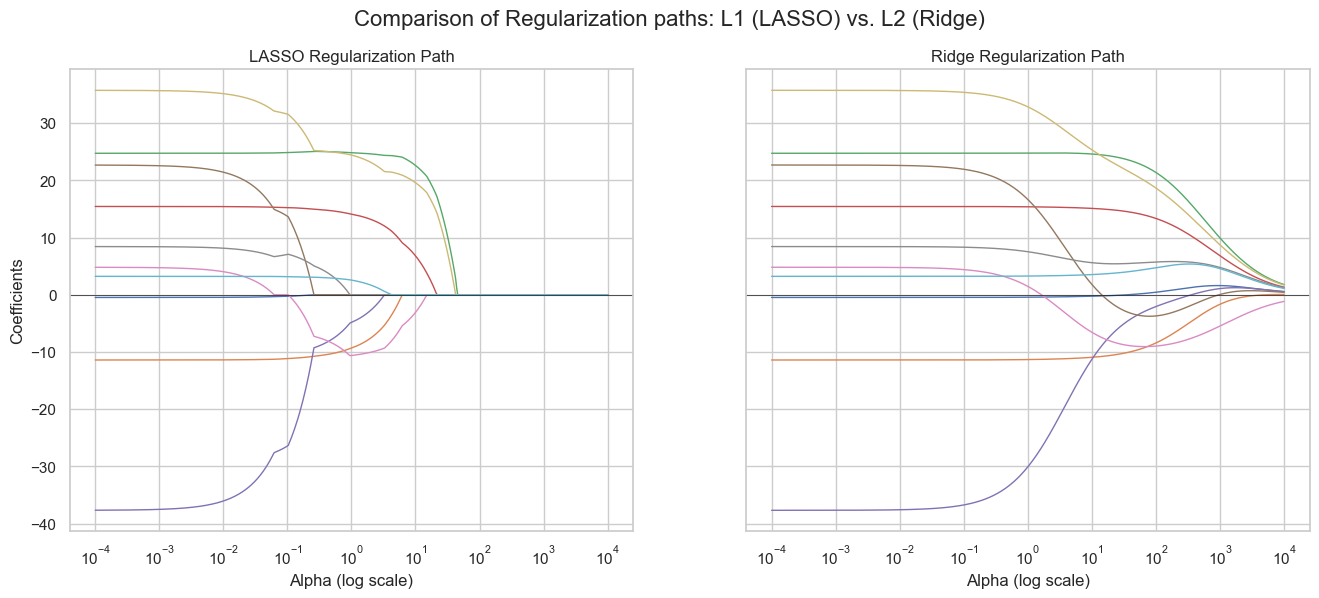

In [17]:
# We'll use the diabetes dataset for the regularization path example. That's a commonly used dataset in regression tasks. It contains 10 features related to diabetes progression and a target variable indicating disease progression one year after the baseline.

diabetes = load_diabetes()
X_path, y_path = diabetes.data, diabetes.target

# Standardize features
scaler = StandardScaler()
X_path_scaled = scaler.fit_transform(X_path)

# Set up the range of lambda (alpha) values for the regularization paths
alphas = np.logspace(-4, 4, 500) # we'll test from 1e-4 to 1e4
coefs_lasso = []
coefs_ridge = []

# TODO: Compute L1/L2 coefficients for each alpha value
for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_path_scaled, y_path)
    coefs_lasso.append(lasso.coef_)
    
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_path_scaled, y_path)
    coefs_ridge.append(ridge.coef_)


# TODO: Plot the regularization paths for both models
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# LASSO
ax1.plot(alphas, coefs_lasso, linewidth=1)
ax1.set_xscale('log')
ax1.set_title('LASSO Regularization Path')
ax1.set_xlabel('Alpha (log scale)')
ax1.set_ylabel('Coefficients')
ax1.axhline(0, color='k', lw=0.5)
ax1.grid(True)

# Ridge
ax2.plot(alphas, coefs_ridge, linewidth=1)
ax2.set_xscale('log')
ax2.set_title('Ridge Regularization Path')
ax2.set_xlabel('Alpha (log scale)')
ax2.axhline(0, color='k', lw=0.5)
ax2.grid(True)

plt.suptitle('Comparison of Regularization paths: L1 (LASSO) vs. L2 (Ridge)', fontsize=16)
plt.show()